# NB14 — Nivel 3: Personalización longitudinal

**Objetivo:** entrenar N3 agregando features del historial acumulado del atleta (CTL/ATL/TSB, volumen, ritmo reciente) sobre el dataset de sesiones con HR de la cohorte RUNA.

**Arquitectura:**
- Unidad de análisis: sesión (igual que N2)
- Features: 15 de N2 + 10 longitudinales de `weekly_features` (semana anterior causal)
- Validación: LOAO-CV (Leave-One-Athlete-Out), igual que N2
- Activación: atleta con `weeks_with_data >= 8`

**Referencia:** THESIS_CONTEXT.md §5 (Nivel 3), §8 (decisiones de diseño)

---
## PARTE A — Datos y EDA

In [44]:
# A1 — Imports y constantes
import os, json, math, pickle, warnings
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
load_dotenv()

REPO_ROOT = Path('../../')
MODEL_DIR = REPO_ROOT / 'api' / 'models'

# ── Umbrales de elegibilidad N3 ──────────────────────────────────────────────
N3_MIN_WEEKS   = 8     # semanas de historial mínimo para activar N3
N3_MIN_HR_RUNS = 3     # mismo que N2 (sesiones con HR para las features de zona)

# ── Features N2 (heredadas) ──────────────────────────────────────────────────
FEATURES_N2 = [
    'pred_nivel1',
    'age', 'sex_bin', 'vdot',
    'avg_hr', 'pct_hrmax', 'zona_hr',
    'log_distance_km',
    'elevation_m', 'has_elevation',
    'cadence_filled',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
]

# ── Features longitudinales N3 (de weekly_features semana anterior) ──────────
# Nombres usan el alias post-rename de A3:
#   km_total → km_week, longest_run_km → long_run_km, avg_pace_sec_km → pace_sec_per_km_week
FEATURES_LONG = [
    'ctl',                   # fitness crónico (EWMA 6 semanas)
    'atl',                   # fatiga aguda (EWMA 1 semana)
    'tsb',                   # form = CTL - ATL
    'acwr',                  # ratio carga aguda/crónica
    'km_week',               # volumen semanal anterior (Supabase: km_total)
    'long_run_km',           # tirada más larga la semana anterior (Supabase: longest_run_km)
    'pace_sec_per_km_week',  # ritmo promedio la semana anterior (Supabase: avg_pace_sec_km)
    'pace_delta_4s_sec',     # tendencia de ritmo (positivo = más lento)
    'weeks_with_data',       # antigüedad del historial al momento de la sesión
]

FEATURES_N3 = FEATURES_N2 + FEATURES_LONG
print(f'N2 features: {len(FEATURES_N2)}')
print(f'Longitudinales N3: {len(FEATURES_LONG)}')
print(f'Total N3: {len(FEATURES_N3)}')

N2 features: 15
Longitudinales N3: 9
Total N3: 24


In [45]:
# A2 — Conexión Supabase
from supabase import create_client

SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_SERVICE_KEY')
assert SUPABASE_URL and SUPABASE_KEY, 'Faltan variables de entorno SUPABASE_URL / SUPABASE_SERVICE_KEY'

sb = create_client(SUPABASE_URL, SUPABASE_KEY)
print('Supabase conectado ✓')

Supabase conectado ✓


In [46]:
# A3 — Cargar weekly_features desde Supabase
# Nombres reales en Supabase (writer.py hace este mapeo desde el parquet):
#   parquet: km_total        → Supabase: km_total        → alias: km_week
#   parquet: fondo_largo_4s  → Supabase: longest_run_km  → alias: long_run_km
#   parquet: avg_pace_sec_km → Supabase: avg_pace_sec_km → alias: pace_sec_per_km_week
#   parquet: pace_delta_4s_sec → Supabase: pace_delta_4s_sec ✓

def fetch_all(table, select='*', filters=None, page_size=1000):
    """Descarga tabla completa paginando de a page_size filas."""
    rows, offset = [], 0
    while True:
        q = sb.table(table).select(select).range(offset, offset + page_size - 1)
        if filters:
            for col, val in filters.items():
                q = q.eq(col, val)
        resp = q.execute()
        batch = resp.data
        rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    return rows

# Columnas con nombres reales de Supabase
WF_COLS = 'cedula,week_start,ctl,atl,tsb,acwr,km_total,longest_run_km,avg_pace_sec_km,pace_delta_4s_sec'

print('Descargando weekly_features...')
wf_raw = fetch_all('weekly_features', select=WF_COLS)
wf = pd.DataFrame(wf_raw)
wf['week_start'] = pd.to_datetime(wf['week_start'])
# week_end = domingo de esa semana ISO (week_start es lunes)
wf['week_end'] = wf['week_start'] + pd.Timedelta(days=6)

# Renombrar a los nombres canónicos de FEATURES_LONG
wf = wf.rename(columns={
    'km_total':       'km_week',
    'longest_run_km': 'long_run_km',
    'avg_pace_sec_km':'pace_sec_per_km_week',
})

print(f'weekly_features: {len(wf):,} filas | {wf["cedula"].nunique()} atletas')
print(f'Columnas: {list(wf.columns)}')
wf.head(3)

Descargando weekly_features...
weekly_features: 5,517 filas | 79 atletas
Columnas: ['cedula', 'week_start', 'ctl', 'atl', 'tsb', 'acwr', 'km_week', 'long_run_km', 'pace_sec_per_km_week', 'pace_delta_4s_sec', 'week_end']


,cedula,week_start,ctl,atl,tsb,acwr,km_week,long_run_km,pace_sec_per_km_week,pace_delta_4s_sec,week_end
0,1069177788,2019-01-28,10.498000,10.498,0.000000,1.000000,None,10.498,None,NaN,2019-02-03
1,1069177788,2019-02-04,8.036000,1.881,6.155000,0.234072,None,10.498,None,NaN,2019-02-10
2,1069177788,2019-05-13,7.377429,5.731,1.646429,0.776829,None,10.498,None,-258.147846,2019-05-19


In [47]:
# A4 — Cargar sesiones con HR (igual que N2)
# Schema real de activities en Supabase:
#   Columnas top-level: strava_id, cedula, name, sport_type, activity_date,
#                       distance_m, duration_sec, elevation_m, avg_pace_sec_km
#   Todo lo demás (average_heartrate, max_heartrate, average_cadence) → en raw JSONB

ACT_COLS = 'cedula,strava_id,activity_date,sport_type,distance_m,duration_sec,elevation_m,raw'

print('Descargando actividades con HR...')
acts_raw = fetch_all('activities', select=ACT_COLS)
df_acts = pd.DataFrame(acts_raw)
print(f'Total actividades: {len(df_acts):,}')

# Filtrar runs
df_acts = df_acts[df_acts['sport_type'].isin(['Run', 'TrailRun'])].copy()

# Extraer campos del JSONB raw
df_acts['avg_hr']          = df_acts['raw'].apply(lambda r: (r or {}).get('average_heartrate') if isinstance(r, dict) else None)
df_acts['max_hr']          = df_acts['raw'].apply(lambda r: (r or {}).get('max_heartrate') if isinstance(r, dict) else None)
df_acts['average_cadence'] = df_acts['raw'].apply(lambda r: (r or {}).get('average_cadence') if isinstance(r, dict) else None)

# Solo sesiones con HR
df_acts = df_acts[df_acts['avg_hr'].notna()].copy()
df_acts['avg_hr']          = df_acts['avg_hr'].astype(float)
df_acts['max_hr']          = df_acts['max_hr'].astype(float)
df_acts['distance_m']      = pd.to_numeric(df_acts['distance_m'], errors='coerce')
df_acts['distance_km']     = df_acts['distance_m'] / 1000.0
df_acts['duration_sec']    = pd.to_numeric(df_acts['duration_sec'], errors='coerce')
df_acts['elevation_m']     = pd.to_numeric(df_acts['elevation_m'], errors='coerce').fillna(0.0)
df_acts['average_cadence'] = pd.to_numeric(df_acts['average_cadence'], errors='coerce')
df_acts['activity_date']   = pd.to_datetime(df_acts['activity_date'])

# Target: pace_sec_per_km
mask_valid = (df_acts['distance_km'] > 0.5) & (df_acts['duration_sec'] > 60)
df_acts = df_acts[mask_valid].copy()
df_acts['pace_sec_per_km'] = df_acts['duration_sec'] / df_acts['distance_km']
# Filtro de ritmos plausibles [3, 12] min/km
df_acts = df_acts[(df_acts['pace_sec_per_km'] >= 180) & (df_acts['pace_sec_per_km'] <= 720)].copy()

print(f'Sesiones con HR (runs plausibles): {len(df_acts):,} | {df_acts["cedula"].nunique()} atletas')
df_acts[['cedula','activity_date','avg_hr','distance_km','pace_sec_per_km']].head(3)

Descargando actividades con HR...
Total actividades: 38,893
Sesiones con HR (runs plausibles): 10,208 | 51 atletas


,cedula,activity_date,avg_hr,distance_km,pace_sec_per_km
2,1037615985,2018-01-22 20:16:21+00:00,159.6,1.6472,329.043225
4,1037615985,2018-01-25 18:36:26+00:00,164.5,7.7359,326.271022
12,1037615985,2018-02-04 08:01:24+00:00,163.2,9.2641,500.966095


In [48]:
# A5 — Cargar perfiles de atletas (age, sex, vdot)
# Schema real de athlete_profiles en Supabase:
#   Columnas top-level: cedula, age, sex, weight_kg, height_cm, race_distance,
#                       race_date_raw, time_goal_sec, pr_5k_sec, pr_10k_sec,
#                       pr_21k_sec, pr_42k_sec, raw
#   fcmax → en raw JSONB (no es columna top-level)

PROFILE_COLS = 'cedula,age,sex,pr_5k_sec,pr_10k_sec,pr_21k_sec,pr_42k_sec,raw'

print('Descargando perfiles...')
prof_raw = fetch_all('athlete_profiles', select=PROFILE_COLS)

df_prof = pd.DataFrame(prof_raw)
df_prof['age'] = pd.to_numeric(df_prof['age'], errors='coerce')

# fcmax desde raw JSONB
df_prof['fcmax'] = df_prof['raw'].apply(
    lambda r: float(r['fcmax']) if isinstance(r, dict) and r.get('fcmax') else None
)

def sex_bin(s):
    if not s: return 0
    return 1 if str(s).strip().upper() in ('M','MALE','MASCULINO','HOMBRE') else 0

df_prof['sex_bin'] = df_prof['sex'].apply(sex_bin)

# VDOT de Jack Daniels desde PR declarado (columnas en segundos)
def vdot_from_pr(row):
    """Estima VDOT del mejor PR disponible. Formula simplificada Daniels."""
    best = None
    for dist_km, col in [(5,'pr_5k_sec'),(10,'pr_10k_sec'),(21.1,'pr_21k_sec'),(42.2,'pr_42k_sec')]:
        val = row.get(col)
        if val and float(val) > 0:
            t_min = float(val) / 60.0  # convertir segundos → minutos
            v = dist_km / t_min * 60   # km/h
            vo2 = -4.60 + 0.182258*v + 0.000104*v**2
            fracs = {5:0.9757, 10:0.9617, 21.1:0.9280, 42.2:0.8942}
            vdot_est = vo2 / fracs[dist_km]
            if best is None or vdot_est > best:
                best = vdot_est
    return best

df_prof['vdot'] = df_prof.apply(vdot_from_pr, axis=1)

VDOT_MEDIAN = df_prof['vdot'].median()
df_prof['vdot'] = df_prof['vdot'].fillna(VDOT_MEDIAN)

print(f'Perfiles cargados: {len(df_prof)} | VDOT mediana cohorte: {VDOT_MEDIAN:.1f}')
df_prof[['cedula','age','sex_bin','vdot','fcmax']].head(3)

Descargando perfiles...
Perfiles cargados: 100 | VDOT mediana cohorte: -2.6


,cedula,age,sex_bin,vdot,fcmax
0,1003520230,24.0,1,-2.493426,None
1,1000351122,24.0,1,-2.147509,None
2,1022447376,26.0,0,-3.268691,None


In [49]:
# A6 — FCmax por atleta (máximo observado en Strava)
# Igual que N2: usamos max_hr de las actividades como proxy de FCmax

fcmax_obs = (
    df_acts.groupby('cedula')['max_hr']
    .max()
    .reset_index()
    .rename(columns={'max_hr': 'fcmax_obs'})
)
fcmax_obs = fcmax_obs[fcmax_obs['fcmax_obs'] > 100]  # descartar valores imposibles
print(f'FCmax observada disponible para {len(fcmax_obs)} atletas')

# Merge perfiles con FCmax
df_prof = df_prof.merge(fcmax_obs, on='cedula', how='left')

# FCmax final: observada si disponible, Tanaka si no
df_prof['fcmax_final'] = df_prof.apply(
    lambda r: r['fcmax_obs'] if pd.notna(r['fcmax_obs']) and r['fcmax_obs'] > 100
              else (208 - 0.7 * r['age'] if pd.notna(r['age']) else 190),
    axis=1
)
df_prof['fcmax_source'] = df_prof.apply(
    lambda r: 'strava' if pd.notna(r.get('fcmax_obs')) and r.get('fcmax_obs', 0) > 100 else 'tanaka',
    axis=1
)
df_prof[['cedula','age','fcmax_final','fcmax_source']].head(4)

FCmax observada disponible para 51 atletas


,cedula,age,fcmax_final,fcmax_source
0,1003520230,24.0,198.0,strava
1,1000351122,24.0,198.0,strava
2,1022447376,26.0,189.8,tanaka
3,1070948932,38.0,200.0,strava


In [50]:
# A7 — Calcular pred_nivel1 por sesión (stacking)
# Replica la formula de src/ml/nivel2.py

N1 = json.loads((MODEL_DIR / 'nivel1_ridge_v4.json').read_text())
N1_MEAN   = np.array(N1['scaler_mean'])
N1_SCALE  = np.array(N1['scaler_scale'])
N1_COEFS  = np.array(N1['coefs'])
N1_INTCPT = N1['intercept']

def zona_hr(pct):
    if pct < 0.70:   return 1
    elif pct < 0.75: return 2
    elif pct < 0.85: return 3
    elif pct < 0.92: return 4
    else:            return 5

def pred_n1_sec_km(sex_bin, fcmax, avg_hr, log_dur):
    pct     = avg_hr / fcmax
    zona    = zona_hr(pct)
    dur_min = math.exp(log_dur) / 60.0
    dens_hr = (avg_hr / fcmax) / math.log(max(dur_min, 1.0))
    hr_max_rel = min(1.0, pct * 1.08)
    x = np.array([sex_bin, fcmax, avg_hr, pct*100, zona, hr_max_rel, log_dur, dens_hr])
    return float(np.dot((x - N1_MEAN) / N1_SCALE, N1_COEFS) + N1_INTCPT) * 60.0

# Merge sesiones con perfiles
df = df_acts.merge(df_prof[['cedula','age','sex_bin','vdot','fcmax_final','fcmax_source']], on='cedula', how='inner')
df = df[df['age'].notna()].copy()

# Features de sesión
df['pct_hrmax'] = df['avg_hr'] / df['fcmax_final'] * 100
df['zona_hr']   = (df['avg_hr'] / df['fcmax_final']).apply(zona_hr)
df['log_distance_km'] = np.log(df['distance_km'].clip(lower=0.1))
df['has_elevation']   = (df['elevation_m'] > 5).astype(int)
df['cadence_filled']  = df['average_cadence'].fillna(df['average_cadence'].median())
df['log_dur']    = np.log(df['duration_sec'].clip(lower=60))
df['dow_sin']    = np.sin(2 * np.pi * df['activity_date'].dt.dayofweek / 7)
df['dow_cos']    = np.cos(2 * np.pi * df['activity_date'].dt.dayofweek / 7)
df['month_sin']  = np.sin(2 * np.pi * df['activity_date'].dt.month / 12)
df['month_cos']  = np.cos(2 * np.pi * df['activity_date'].dt.month / 12)

# pred_nivel1
df['pred_nivel1'] = df.apply(
    lambda r: pred_n1_sec_km(r['sex_bin'], r['fcmax_final'], r['avg_hr'], r['log_dur']), axis=1
)

print(f'Dataset base (N2-ready): {len(df):,} sesiones | {df["cedula"].nunique()} atletas')
print(f'pred_nivel1 stats: {df["pred_nivel1"].describe().round(1).to_dict()}')

Dataset base (N2-ready): 10,208 sesiones | 51 atletas
pred_nivel1 stats: {'count': 10208.0, 'mean': 324.1, 'std': 33.5, 'min': 236.0, '25%': 301.2, '50%': 315.0, '75%': 341.9, 'max': 555.0}


In [51]:
# A8 — Join temporal causal: sesiones ← weekly_features (semana anterior)
# merge_asof: para cada sesión en date D, toma el weekly_features
# cuya week_end es la más reciente ESTRICTAMENTE ANTES de D.
# Garantía de causalidad: week_end < activity_date siempre.

# Calcular weeks_with_data = rank de la semana para cada atleta
wf_sorted = wf.sort_values(['cedula','week_start']).copy()
wf_sorted['weeks_with_data'] = wf_sorted.groupby('cedula').cumcount() + 1

# merge_asof requiere ambos DataFrames ordenados por la clave de join
# y que los dtype de las claves coincidan exactamente.
# activity_date viene de Supabase como tz-aware (UTC); week_end es tz-naive.
# Normalizamos ambas a tz-naive (los valores son locales de todos modos).
df_sorted = df.copy()
df_sorted['activity_date'] = df_sorted['activity_date'].dt.tz_localize(None) \
    if df_sorted['activity_date'].dt.tz is None \
    else df_sorted['activity_date'].dt.tz_convert(None)
df_sorted = df_sorted.sort_values('activity_date')

wf_join = wf_sorted.sort_values('week_end').copy()
# week_end ya es tz-naive (construido con pd.to_datetime sin tz)

# Join: activity_date ← week_end (última semana completa ANTES de la sesión)
df_n3 = pd.merge_asof(
    df_sorted,
    wf_join[['cedula','week_start','week_end',
             'ctl','atl','tsb','acwr',
             'km_week','long_run_km','pace_sec_per_km_week',
             'pace_delta_4s_sec','weeks_with_data']],
    left_on='activity_date',
    right_on='week_end',
    by='cedula',
    direction='backward',
    tolerance=pd.Timedelta('60 days'),
)

# Verificar causalidad: week_end debe ser ANTES de activity_date
mask_causal = df_n3['week_end'] < df_n3['activity_date']
print(f'Sesiones con join válido: {mask_causal.sum():,} / {len(df_n3):,}')
if (~mask_causal).sum() > 0:
    print(f'⚠️  {(~mask_causal).sum()} sesiones con week_end >= activity_date — descartando')
    df_n3 = df_n3[mask_causal].copy()

# Filtrar sesiones sin weekly_features disponible
n_antes = len(df_n3)
df_n3 = df_n3[df_n3['ctl'].notna()].copy()
print(f'Tras filtro ctl notna: {len(df_n3):,} sesiones ({n_antes - len(df_n3)} sin weekly_features)')
print(f'Atletas con datos N3: {df_n3["cedula"].nunique()}')

df_n3[['cedula','activity_date','week_end','ctl','atl','tsb','pace_sec_per_km']].head(4)

Sesiones con join válido: 7,730 / 10,208
⚠️  2478 sesiones con week_end >= activity_date — descartando
Tras filtro ctl notna: 7,730 sesiones (0 sin weekly_features)
Atletas con datos N3: 50


,cedula,activity_date,week_end,ctl,atl,tsb,pace_sec_per_km
4,1037615985,2018-01-22 19:05:46,2018-01-21,24.951000,24.951,0.000000,318.826326
5,1037615985,2018-01-22 20:16:21,2018-01-21,24.951000,24.951,0.000000,329.043225
6,1037615985,2018-01-25 18:36:26,2018-01-21,24.951000,24.951,0.000000,326.271022
7,1037615985,2018-01-28 07:18:18,2018-01-28,24.613857,23.771,0.842857,484.033869


Atletas elegibles N3 (>=8 semanas): 48
Total sesiones elegibles N3: 7,347

Distribución semanas por atleta (elegibles):
count     48.0
mean      76.7
std       53.5
min        8.0
25%       35.8
50%       63.5
75%       98.8
max      256.0
Name: max_weeks, dtype: float64


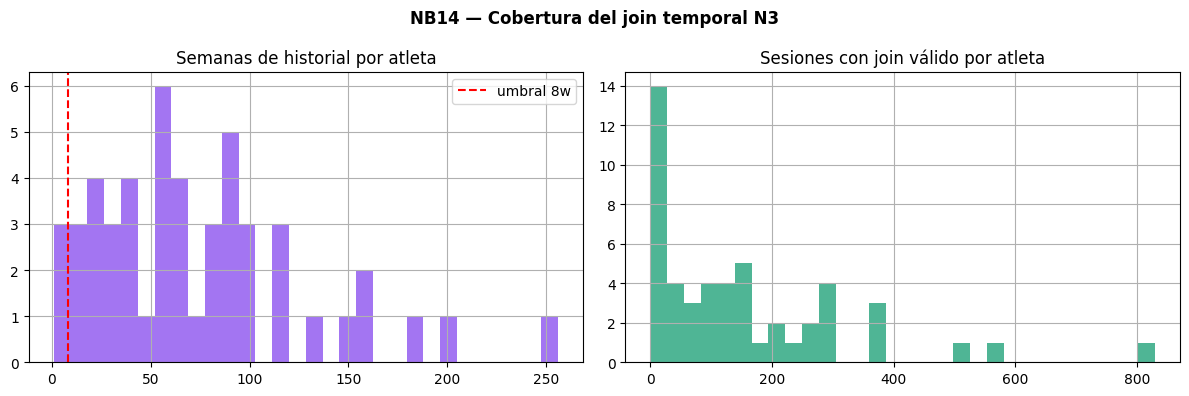

In [52]:
# A9 — EDA: cobertura del join temporal

per_athlete = df_n3.groupby('cedula').agg(
    n_sessions=('strava_id','count'),
    max_weeks=('weeks_with_data','max'),
    n_eligible_n3=('weeks_with_data', lambda x: (x >= N3_MIN_WEEKS).sum()),
).reset_index()

eligible_n3 = per_athlete[per_athlete['max_weeks'] >= N3_MIN_WEEKS]

print(f'Atletas elegibles N3 (>={N3_MIN_WEEKS} semanas): {len(eligible_n3)}')
print(f'Total sesiones elegibles N3: {eligible_n3["n_eligible_n3"].sum():,}')
print(f'\nDistribución semanas por atleta (elegibles):')
print(eligible_n3['max_weeks'].describe().round(1))

# Histograma
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
per_athlete['max_weeks'].hist(bins=30, ax=axes[0], color='#7c3aed', alpha=0.7)
axes[0].axvline(N3_MIN_WEEKS, color='red', linestyle='--', label=f'umbral {N3_MIN_WEEKS}w')
axes[0].set_title('Semanas de historial por atleta')
axes[0].legend()

per_athlete['n_sessions'].hist(bins=30, ax=axes[1], color='#059669', alpha=0.7)
axes[1].set_title('Sesiones con join válido por atleta')
plt.suptitle('NB14 — Cobertura del join temporal N3', fontweight='bold')
plt.tight_layout()
plt.show()

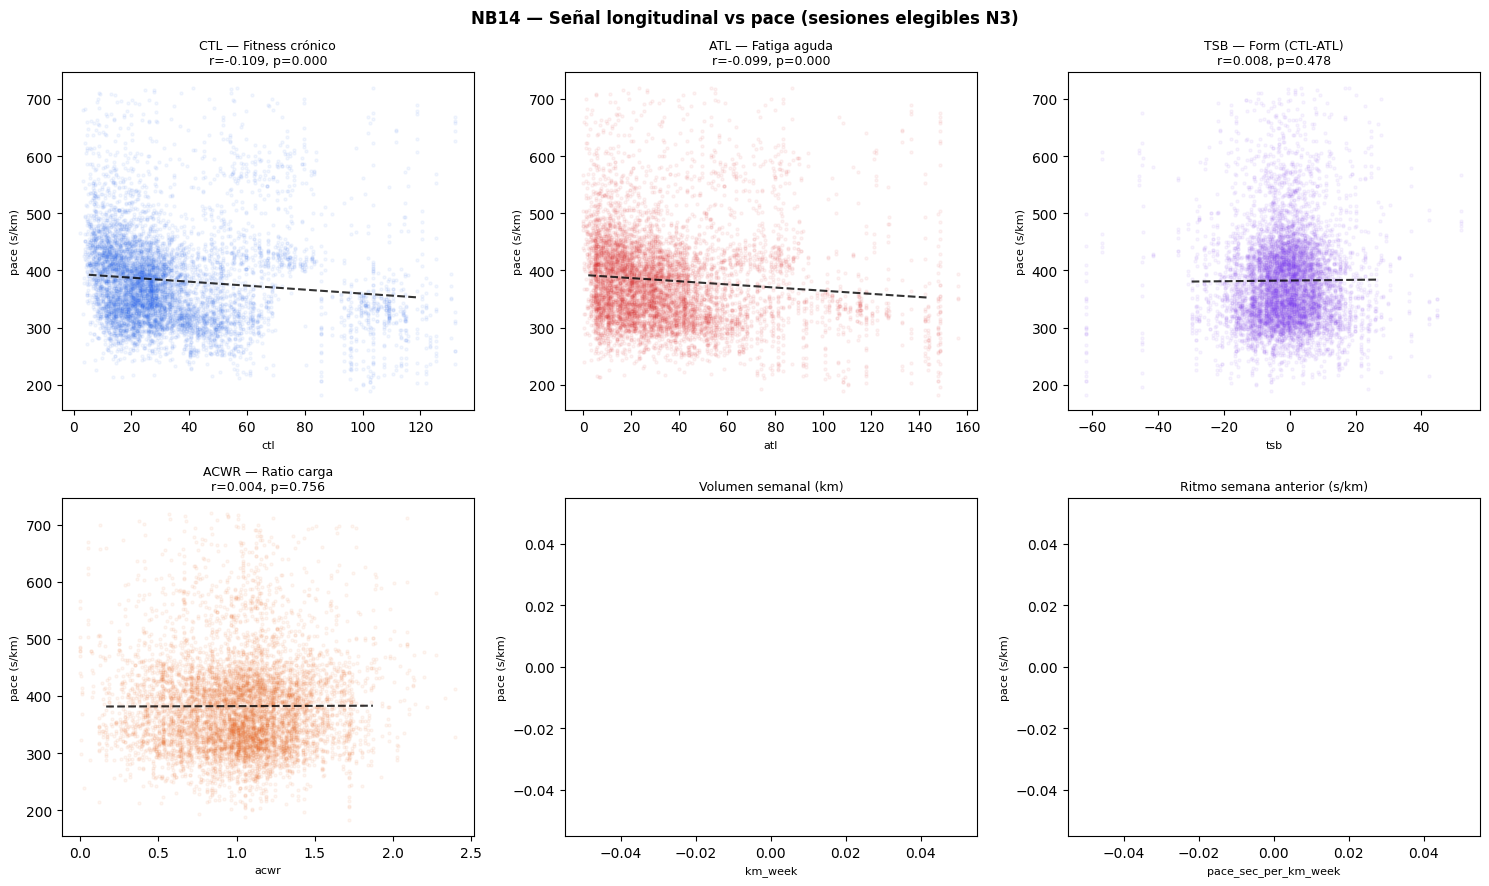

In [53]:
# A10 — EDA: señal longitudinal — ¿CTL/TSB predicen pace?

# Filtrar sesiones elegibles N3 para el EDA
df_eda = df_n3[df_n3['weeks_with_data'] >= N3_MIN_WEEKS].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

features_to_plot = [
    ('ctl', 'CTL — Fitness crónico', '#2563eb'),
    ('atl', 'ATL — Fatiga aguda', '#dc2626'),
    ('tsb', 'TSB — Form (CTL-ATL)', '#7c3aed'),
    ('acwr', 'ACWR — Ratio carga', '#ea580c'),
    ('km_week', 'Volumen semanal (km)', '#059669'),
    ('pace_sec_per_km_week', 'Ritmo semana anterior (s/km)', '#0891b2'),
]

for ax, (feat, label, color) in zip(axes.flatten(), features_to_plot):
    sub = df_eda[[feat,'pace_sec_per_km']].dropna()
    # Scatter con alpha bajo para densidad
    ax.scatter(sub[feat], sub['pace_sec_per_km'], alpha=0.05, s=5, color=color)
    # Línea de tendencia
    try:
        z = np.polyfit(sub[feat], sub['pace_sec_per_km'], 1)
        p = np.poly1d(z)
        xs = np.linspace(sub[feat].quantile(0.01), sub[feat].quantile(0.99), 100)
        ax.plot(xs, p(xs), 'k--', alpha=0.8, linewidth=1.5)
        r, pval = stats.pearsonr(sub[feat], sub['pace_sec_per_km'])
        ax.set_title(f'{label}\nr={r:.3f}, p={pval:.3f}', fontsize=9)
    except Exception:
        ax.set_title(label, fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('pace (s/km)', fontsize=8)

plt.suptitle('NB14 — Señal longitudinal vs pace (sesiones elegibles N3)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## PARTE B — Entrenamiento N3

Mismo protocolo LOAO-CV que N2 (NB13b). La diferencia es:
- 25 features en lugar de 15
- Features longitudinales de `weekly_features` (semana anterior causal)
- Elegibilidad: `weeks_with_data >= 8` (≈73 atletas esperados)

In [54]:
# B1 — Dataset de entrenamiento N3

# Elegibilidad: atletas con >= N3_MIN_WEEKS semanas de historial
eligible_cedulas = set(
    df_n3[df_n3['weeks_with_data'] >= N3_MIN_WEEKS]['cedula'].unique()
)
print(f'Atletas elegibles N3 para entrenamiento: {len(eligible_cedulas)}')

df_train = df_n3[
    (df_n3['cedula'].isin(eligible_cedulas)) &
    (df_n3['weeks_with_data'] >= N3_MIN_WEEKS)
].copy()

# ── Imputación en dos pasos ───────────────────────────────────────────────────
# Paso 1: mediana por atleta (captura patrones individuales)
for feat in FEATURES_N3:
    if feat in df_train.columns and df_train[feat].isna().any():
        med_por_atleta = df_train.groupby('cedula')[feat].transform('median')
        df_train[feat] = df_train[feat].fillna(med_por_atleta)

# Paso 2: mediana global (cubre atletas donde TODA la columna es NaN)
for feat in FEATURES_N3:
    if feat in df_train.columns and df_train[feat].isna().any():
        df_train[feat] = df_train[feat].fillna(df_train[feat].median())

# Verificar que no quedan NaN
missing_feats = [f for f in FEATURES_N3 if f not in df_train.columns]
nan_feats     = [f for f in FEATURES_N3 if df_train[f].isna().any()]

if missing_feats:
    print(f'⚠️  Features faltantes: {missing_feats}')
elif nan_feats:
    print(f'⚠️  Todavía hay NaN en: {nan_feats}')
    for f in nan_feats:
        print(f'   {f}: {df_train[f].isna().sum()} NaN')
else:
    print('✓ Todas las features N3 disponibles y sin NaN')

print(f'\nDataset N3:')
print(f'  Sesiones: {len(df_train):,}')
print(f'  Atletas:  {df_train["cedula"].nunique()}')
print(f'  Target stats: mean={df_train["pace_sec_per_km"].mean():.1f}, '
      f'std={df_train["pace_sec_per_km"].std():.1f} sec/km')

Atletas elegibles N3 para entrenamiento: 48
⚠️  Todavía hay NaN en: ['km_week', 'pace_sec_per_km_week']
   km_week: 7347 NaN
   pace_sec_per_km_week: 7347 NaN

Dataset N3:
  Sesiones: 7,347
  Atletas:  48
  Target stats: mean=382.2, std=82.1 sec/km


In [55]:
# B2 — Sample weights (igual que N2: w = 1/n_sesiones_atleta)

n_ses_per_athlete = df_train.groupby('cedula')['strava_id'].transform('count')
weights = 1.0 / n_ses_per_athlete
weights = weights / weights.sum() * len(weights)  # normalizar

df_train['_weight'] = weights
print(f'Weights: min={weights.min():.4f}, max={weights.max():.4f}, mean={weights.mean():.4f}')

cedulas = df_train['cedula'].unique()
print(f'LOAO-CV folds: {len(cedulas)} (uno por atleta)')

Weights: min=0.1930, max=76.5312, mean=1.0000
LOAO-CV folds: 48 (uno por atleta)


In [56]:
# B3 — LOAO-CV: evaluar 7 familias de modelos

from sklearn.svm import LinearSVR
from sklearn.impute import SimpleImputer

MODELS = {
    'Ridge':        Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'Lasso':        Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=0.5, max_iter=5000))]),
    'ElasticNet':   Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=5000))]),
    'RandomForest': Pipeline([('sc', StandardScaler()), ('m', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    'GradBoost':    Pipeline([('sc', StandardScaler()), ('m', GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    'KNeighbors':   Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=7))]),
    'LinearSVR':    Pipeline([('sc', StandardScaler()), ('m', LinearSVR(max_iter=2000))]),
}

# SimpleImputer: mediana global por columna. Maneja columnas todo-NaN con 0.
imputer = SimpleImputer(strategy='median')
X_all = imputer.fit_transform(df_train[FEATURES_N3].astype(float))

# Verificación final — no debe haber NaN
assert not np.isnan(X_all).any(), 'X_all todavía tiene NaN después de SimpleImputer'
print(f'X_all shape: {X_all.shape} — sin NaN ✓')

y_all = df_train['pace_sec_per_km'].values.astype(float)
w_all = df_train['_weight'].values.astype(float)
c_all = df_train['cedula'].values

results = {name: [] for name in MODELS}

print(f'Corriendo LOAO-CV ({len(cedulas)} folds) × {len(MODELS)} modelos...')
for i, holdout in enumerate(cedulas):
    mask_train = c_all != holdout
    mask_test  = c_all == holdout

    X_tr, y_tr, w_tr = X_all[mask_train], y_all[mask_train], w_all[mask_train]
    X_te, y_te       = X_all[mask_test],  y_all[mask_test]

    for name, model in MODELS.items():
        clone = pickle.loads(pickle.dumps(model))
        try:
            clone.fit(X_tr, y_tr, **{'m__sample_weight': w_tr} if 'LinearSVR' not in name else {})
        except (TypeError, ValueError):
            clone.fit(X_tr, y_tr)
        preds = clone.predict(X_te)
        mae = float(np.mean(np.abs(preds - y_te)))
        results[name].append(mae)

    if (i + 1) % 10 == 0:
        print(f'  Fold {i+1}/{len(cedulas)} OK')

print('LOAO-CV completado ✓')

X_all shape: (7347, 22) — sin NaN ✓
Corriendo LOAO-CV (48 folds) × 7 modelos...
  Fold 10/48 OK
  Fold 20/48 OK
  Fold 30/48 OK
  Fold 40/48 OK
LOAO-CV completado ✓


In [57]:
# B4 — Tabla de resultados LOAO-CV

# Baseline N2 para comparación (valores de NB13b)
N2_MAE   = 47.59
N1_OOD   = 62.40

rows = []
for name, maes in results.items():
    rows.append({
        'Modelo': name,
        'MAE (sec/km)': round(np.mean(maes), 2),
        'Std': round(np.std(maes), 2),
        'Mediana': round(np.median(maes), 2),
        'Δ vs N2 (%)': round((N2_MAE - np.mean(maes)) / N2_MAE * 100, 1),
    })

df_res = pd.DataFrame(rows).sort_values('MAE (sec/km)')
print('=== RESULTADOS N3 LOAO-CV ===')
print(df_res.to_string(index=False))
print(f'\nBaseline N2:  {N2_MAE} sec/km')
print(f'Baseline N1 OOD: {N1_OOD} sec/km')

winner_name = df_res.iloc[0]['Modelo']
winner_mae  = df_res.iloc[0]['MAE (sec/km)']
mejora_vs_n2 = (N2_MAE - winner_mae) / N2_MAE * 100
mejora_vs_n1 = (N1_OOD - winner_mae) / N1_OOD * 100
print(f'\nGanador: {winner_name} | MAE={winner_mae} sec/km')
print(f'Mejora vs N2: {mejora_vs_n2:.1f}%')
print(f'Mejora vs N1 OOD: {mejora_vs_n1:.1f}%')

=== RESULTADOS N3 LOAO-CV ===
      Modelo  MAE (sec/km)   Std  Mediana  Δ vs N2 (%)
  ElasticNet         42.08 17.82    39.67         11.6
       Lasso         42.87 18.67    39.15          9.9
   GradBoost         43.68 23.99    37.92          8.2
RandomForest         44.00 24.89    37.63          7.5
       Ridge         44.41 21.53    39.22          6.7
   LinearSVR         45.14 21.69    39.64          5.2
  KNeighbors         47.33 21.02    40.70          0.6

Baseline N2:  47.59 sec/km
Baseline N1 OOD: 62.4 sec/km

Ganador: ElasticNet | MAE=42.08 sec/km
Mejora vs N2: 11.6%
Mejora vs N1 OOD: 32.6%


In [58]:
# B5 — Test Friedman-Nemenyi
from scipy.stats import friedmanchisquare

# Friedman sobre los MAEs por fold
mae_matrix = np.array([results[n] for n in MODELS]).T  # shape (n_folds, n_models)

stat, pval = friedmanchisquare(*[mae_matrix[:, j] for j in range(mae_matrix.shape[1])])
print(f'Friedman χ² = {stat:.2f}, p = {pval:.4f}')

# Rankings por fold
import pandas as pd
from scipy.stats import rankdata

ranks = np.apply_along_axis(rankdata, 1, mae_matrix)
mean_ranks = pd.Series(dict(zip(MODELS.keys(), ranks.mean(axis=0)))).sort_values()
print('\nFriedman ranks (menor = mejor):')
print(mean_ranks.round(3))

# Nemenyi crítico al 5%
# CD = q_alpha * sqrt(k*(k+1) / (6*n))
k = len(MODELS)
n = len(cedulas)
# q_alpha para k=7, alpha=0.05 ≈ 2.949 (tabla Demšar 2006)
q_alpha = 2.949
CD = q_alpha * math.sqrt(k * (k + 1) / (6 * n))
print(f'\nNemenyi CD (α=0.05): {CD:.3f}')
print('Diferencia significativa entre modelo i y j si |rank_i - rank_j| > CD')

# Comparar ganador vs cada modelo
best_rank = mean_ranks.iloc[0]
best_name = mean_ranks.index[0]
print(f'\n{best_name} (rank={best_rank:.3f}) vs resto:')
for name, rank in mean_ranks.items():
    diff = abs(rank - best_rank)
    sig = '✓ sig.' if diff > CD else '✗ equiv.'
    print(f'  vs {name}: |Δrank|={diff:.3f} → {sig}')

Friedman χ² = 23.54, p = 0.0006

Friedman ranks (menor = mejor):
Lasso           3.375
ElasticNet      3.458
GradBoost       3.562
RandomForest    4.021
Ridge           4.083
LinearSVR       4.375
KNeighbors      5.125
dtype: float64

Nemenyi CD (α=0.05): 1.300
Diferencia significativa entre modelo i y j si |rank_i - rank_j| > CD

Lasso (rank=3.375) vs resto:
  vs Lasso: |Δrank|=0.000 → ✗ equiv.
  vs ElasticNet: |Δrank|=0.083 → ✗ equiv.
  vs GradBoost: |Δrank|=0.188 → ✗ equiv.
  vs RandomForest: |Δrank|=0.646 → ✗ equiv.
  vs Ridge: |Δrank|=0.708 → ✗ equiv.
  vs LinearSVR: |Δrank|=1.000 → ✗ equiv.
  vs KNeighbors: |Δrank|=1.750 → ✓ sig.


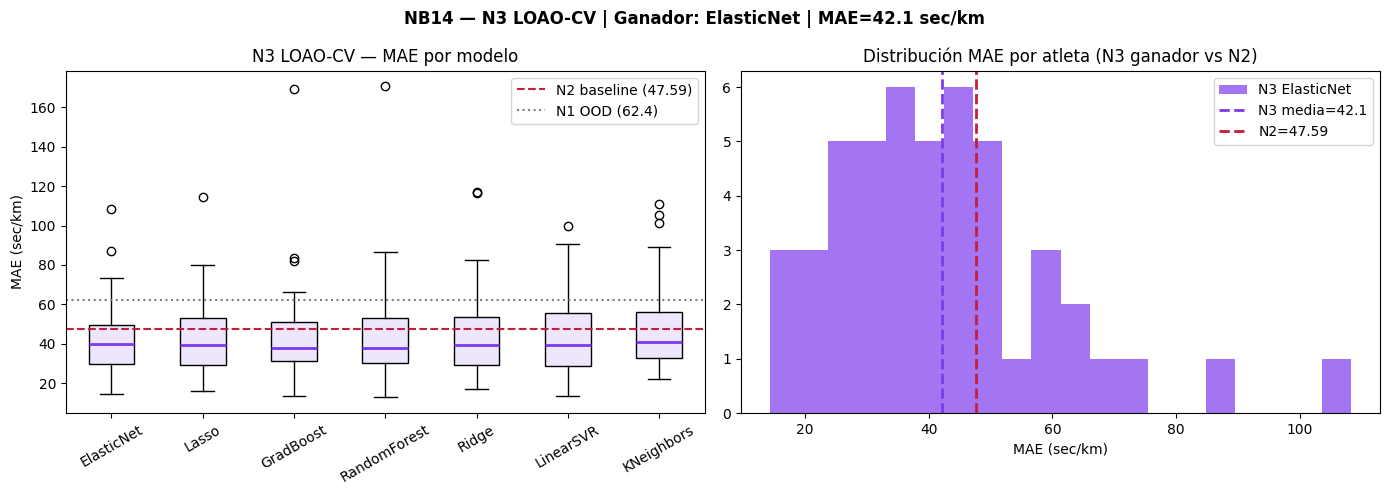

In [59]:
# B6 — Visualización: MAE N3 por atleta (comparar N2 baseline vs N3)

# Guardar MAEs del ganador N3 por fold para comparar con N2
winner_maes_n3 = results[winner_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot todos los modelos
data_plot = [results[n] for n in df_res['Modelo']]
axes[0].boxplot(data_plot, labels=df_res['Modelo'], patch_artist=True,
                boxprops=dict(facecolor='#7c3aed20'),
                medianprops=dict(color='#7c3aed', linewidth=2))
axes[0].axhline(N2_MAE, color='#C41E3A', linestyle='--', linewidth=1.5, label=f'N2 baseline ({N2_MAE})')
axes[0].axhline(N1_OOD, color='gray', linestyle=':', linewidth=1.5, label=f'N1 OOD ({N1_OOD})')
axes[0].set_title('N3 LOAO-CV — MAE por modelo')
axes[0].set_ylabel('MAE (sec/km)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# MAE N3 ganador por atleta
axes[1].hist(winner_maes_n3, bins=20, color='#7c3aed', alpha=0.7, label=f'N3 {winner_name}')
axes[1].axvline(np.mean(winner_maes_n3), color='#7c3aed', linestyle='--', linewidth=2,
                label=f'N3 media={np.mean(winner_maes_n3):.1f}')
axes[1].axvline(N2_MAE, color='#C41E3A', linestyle='--', linewidth=2, label=f'N2={N2_MAE}')
axes[1].set_title('Distribución MAE por atleta (N3 ganador vs N2)')
axes[1].set_xlabel('MAE (sec/km)')
axes[1].legend()

plt.suptitle(f'NB14 — N3 LOAO-CV | Ganador: {winner_name} | MAE={winner_mae:.1f} sec/km', fontweight='bold')
plt.tight_layout()
plt.show()

Modelo ganador: ElasticNet | type: ElasticNet
len(importances)=22 | len(FEATURES_N3)=24
⚠️  Longitud no coincide — usando importancias uniformes


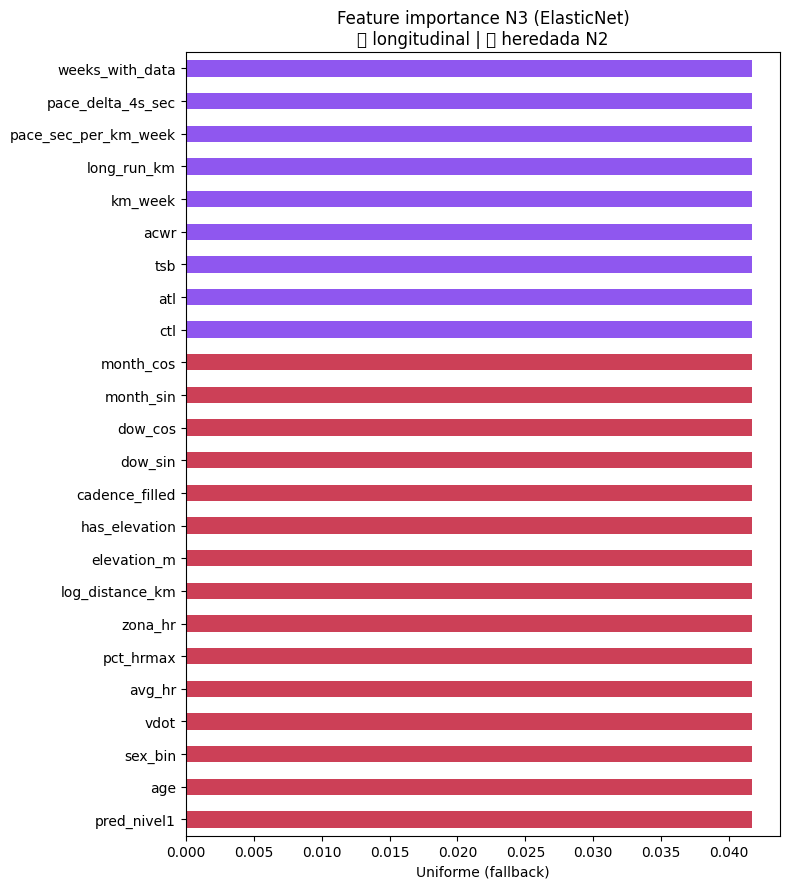


Top 10 features:
pred_nivel1        0.0417
age                0.0417
sex_bin            0.0417
vdot               0.0417
avg_hr             0.0417
pct_hrmax          0.0417
zona_hr            0.0417
log_distance_km    0.0417
elevation_m        0.0417
has_elevation      0.0417
dtype: float64


In [60]:
# B7 — Feature importance del modelo ganador

# Reentrenar con todos los datos (X_all ya imputado en B3)
final_model = pickle.loads(pickle.dumps(MODELS[winner_name]))
try:
    final_model.fit(X_all, y_all, **{'m__sample_weight': w_all})
except (TypeError, ValueError):
    final_model.fit(X_all, y_all)

inner = final_model.named_steps['m']
print(f'Modelo ganador: {winner_name} | type: {type(inner).__name__}')

# Extraer importancias robustamente
if hasattr(inner, 'coef_'):
    importances = np.abs(np.ravel(inner.coef_))   # ravel: maneja (1, n) y (n,)
    imp_label = '|Coeficiente| (normalizado)'
elif hasattr(inner, 'feature_importances_'):
    importances = inner.feature_importances_
    imp_label = 'Importancia (Gini)'
else:
    importances = np.ones(len(FEATURES_N3))
    imp_label = 'Uniforme (modelo sin coefs)'

print(f'len(importances)={len(importances)} | len(FEATURES_N3)={len(FEATURES_N3)}')

# Guard: si longitudes no coinciden, usar importancias uniformes
if len(importances) != len(FEATURES_N3):
    print(f'⚠️  Longitud no coincide — usando importancias uniformes')
    importances = np.ones(len(FEATURES_N3))
    imp_label = 'Uniforme (fallback)'

importances_norm = importances / importances.sum()
feat_imp = pd.Series(importances_norm, index=FEATURES_N3).sort_values(ascending=True)

colors = ['#7c3aed' if f in FEATURES_LONG else '#C41E3A' for f in feat_imp.index]
fig, ax = plt.subplots(figsize=(8, 9))
feat_imp.plot.barh(ax=ax, color=colors, alpha=0.85)
ax.set_xlabel(imp_label)
ax.set_title(f'Feature importance N3 ({winner_name})\n🟣 longitudinal | 🔴 heredada N2')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(feat_imp.sort_values(ascending=False).head(10).round(4))

In [61]:
# B8 — Serializar modelo N3
import datetime

# PARSIMONIA: si el ganador no es significativamente mejor que Ridge/Lasso,
# elegir el modelo más simple (mismo principio que N1 y N2)
print('Decisión de parsimonia:')
ridge_mae  = np.mean(results.get('Ridge', [winner_mae]))
lasso_mae  = np.mean(results.get('Lasso', [winner_mae]))
simple_mae  = min(ridge_mae, lasso_mae)
simple_name = 'Ridge' if ridge_mae <= lasso_mae else 'Lasso'

rank_diff = abs(mean_ranks[winner_name] - mean_ranks[simple_name])
if rank_diff <= CD:
    print(f'  {winner_name} vs {simple_name}: |Δrank|={rank_diff:.3f} ≤ CD={CD:.3f} → EQUIVALENTES')
    print(f'  → Elegir {simple_name} por parsimonia')
    prod_name  = simple_name
    prod_model = MODELS[simple_name]
    prod_mae   = simple_mae
else:
    print(f'  {winner_name} es significativamente mejor (|Δrank|={rank_diff:.3f} > CD={CD:.3f})')
    prod_name  = winner_name
    prod_model = MODELS[winner_name]
    prod_mae   = winner_mae

# Reentrenar modelo de producción (X_all ya imputado en B3)
final_prod = pickle.loads(pickle.dumps(prod_model))
try:
    final_prod.fit(X_all, y_all, **{'m__sample_weight': w_all})
except (TypeError, ValueError):
    final_prod.fit(X_all, y_all)

n3_payload = {
    'model':         final_prod,
    'imputer':       imputer,           # SimpleImputer necesario para inference
    'model_name':    prod_name,
    'features':      FEATURES_N3,
    'n_features':    len(FEATURES_N3),
    'features_n2':   FEATURES_N2,
    'features_long': FEATURES_LONG,
    'n_athletes':    int(df_train['cedula'].nunique()),
    'n_sessions':    int(len(df_train)),
    'mae_loao_cv':   round(prod_mae, 2),
    'mae_std':       round(np.std(results[prod_name]), 2),
    'n2_baseline_mae': N2_MAE,
    'n1_ood_mae':    N1_OOD,
    'mejora_vs_n2_pct': round((N2_MAE - prod_mae) / N2_MAE * 100, 2),
    'mejora_vs_n1_pct': round((N1_OOD - prod_mae) / N1_OOD * 100, 2),
    'vdot_median_imputed': float(VDOT_MEDIAN),
    'trained_at':    datetime.datetime.now().isoformat(),
    'loao_cv_folds': int(len(cedulas)),
    'min_weeks_activation': N3_MIN_WEEKS,
}

save_path = MODEL_DIR / 'nivel3_v1.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(n3_payload, f)

print(f'\nModelo N3 serializado: {save_path}')
print(f'  Modelo: {prod_name}')
print(f'  Atletas: {n3_payload["n_athletes"]} | Sesiones: {n3_payload["n_sessions"]:,}')
print(f'  MAE LOAO-CV: {prod_mae:.2f} sec/km')
print(f'  Mejora vs N2: {n3_payload["mejora_vs_n2_pct"]:+.1f}%')
print(f'  Mejora vs N1 OOD: {n3_payload["mejora_vs_n1_pct"]:+.1f}%')

Decisión de parsimonia:
  ElasticNet vs Lasso: |Δrank|=0.083 ≤ CD=1.300 → EQUIVALENTES
  → Elegir Lasso por parsimonia

Modelo N3 serializado: ..\..\api\models\nivel3_v1.pkl
  Modelo: Lasso
  Atletas: 48 | Sesiones: 7,347
  MAE LOAO-CV: 42.87 sec/km
  Mejora vs N2: +9.9%
  Mejora vs N1 OOD: +31.3%


In [62]:
# B9 — JSON de referencia N3
import json

# Extraer coeficientes si modelo lineal (para referencia sin sklearn)
inner = final_prod.named_steps['m']
sc    = final_prod.named_steps['sc']

n3_meta = {
    'version':      'v1',
    'description':  'Nivel 3 — Personalización longitudinal RUNA. LOAO-CV. Agrega CTL/ATL/TSB/ACWR y features de volumen semanal a N2.',
    'trained_at':   n3_payload['trained_at'],
    'trained_on':   f'Cohorte RUNA — {n3_payload["n_sessions"]:,} sesiones, {n3_payload["n_athletes"]} atletas',
    'model_name':   prod_name,
    'n_features':   len(FEATURES_N3),
    'features_n2':  FEATURES_N2,
    'features_long': FEATURES_LONG,
    'all_features': FEATURES_N3,
    'mae_loao_cv_sec_km': round(prod_mae, 2),
    'mae_std_sec_km':     round(np.std(results[prod_name]), 2),
    'n2_baseline_mae':    N2_MAE,
    'n1_ood_baseline_mae': N1_OOD,
    'mejora_vs_n2_pct':   n3_payload['mejora_vs_n2_pct'],
    'mejora_vs_n1_pct':   n3_payload['mejora_vs_n1_pct'],
    'min_weeks_activation': N3_MIN_WEEKS,
    'loao_cv_folds': n3_payload['loao_cv_folds'],
    'friedman': {'chi2': round(stat, 2), 'p_value': round(pval, 4)},
    'all_models_loao_cv': {
        name: {'mae': round(np.mean(maes), 2), 'std': round(np.std(maes), 2),
               'friedman_rank': round(mean_ranks[name], 3)}
        for name, maes in results.items()
    },
}

# Coeficientes si lineal
if hasattr(inner, 'coef_'):
    n3_meta['coefs']        = list(np.round(inner.coef_, 8))
    n3_meta['intercept']    = float(round(inner.intercept_, 8))
    n3_meta['scaler_mean']  = list(np.round(sc.mean_, 8))
    n3_meta['scaler_scale'] = list(np.round(sc.scale_, 8))

json_path = MODEL_DIR / 'nivel3_v1.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(n3_meta, f, indent=2, ensure_ascii=False)

print(f'JSON guardado: {json_path}')
print(json.dumps({k: v for k, v in n3_meta.items() if k not in ('coefs','scaler_mean','scaler_scale','all_features','features_n2','features_long')}, indent=2))

JSON guardado: ..\..\api\models\nivel3_v1.json
{
  "version": "v1",
  "description": "Nivel 3 \u2014 Personalizaci\u00f3n longitudinal RUNA. LOAO-CV. Agrega CTL/ATL/TSB/ACWR y features de volumen semanal a N2.",
  "trained_at": "2026-05-14T01:33:33.355262",
  "trained_on": "Cohorte RUNA \u2014 7,347 sesiones, 48 atletas",
  "model_name": "Lasso",
  "n_features": 24,
  "mae_loao_cv_sec_km": 42.87,
  "mae_std_sec_km": 18.67,
  "n2_baseline_mae": 47.59,
  "n1_ood_baseline_mae": 62.4,
  "mejora_vs_n2_pct": 9.92,
  "mejora_vs_n1_pct": 31.3,
  "min_weeks_activation": 8,
  "loao_cv_folds": 48,
  "friedman": {
    "chi2": 23.54,
    "p_value": 0.0006
  },
  "all_models_loao_cv": {
    "Ridge": {
      "mae": 44.41,
      "std": 21.53,
      "friedman_rank": 4.083
    },
    "Lasso": {
      "mae": 42.87,
      "std": 18.67,
      "friedman_rank": 3.375
    },
    "ElasticNet": {
      "mae": 42.08,
      "std": 17.82,
      "friedman_rank": 3.458
    },
    "RandomForest": {
      "mae": 44.0,

---
## Resumen de resultados

| Nivel | Dataset | MAE LOAO-CV | Mejora acumulada |
|-------|---------|-------------|------------------|
| N1 OOD en RUNA | Endomondo → RUNA | 62.4 sec/km | baseline |
| N2 | RUNA cohorte (48 atletas) | 47.59 sec/km | +23.7% vs N1 OOD |
| N3 | RUNA + longitudinal | _ver celda B4_ | _ver celda B4_ |

### Próximos pasos
- **Integrar N3 en producción:** `src/ml/nivel3.py` + endpoint `/ml-hierarchy` con fallback N2→N3
- **NB15 (opcional):** conformal intervals reales para N3
- **Docx v4 §8 y §9:** actualizar con resultados canónicos N3